In [4]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider
import mne
mne.set_log_level('ERROR')
warnings.filterwarnings("ignore")
from scipy.signal import butter, filtfilt

# Funciones Auxiliares

In [55]:
def apply_car(eeg_data):
    """Aplica Common Average Referencing de forma vectorizada"""
    return eeg_data - np.mean(eeg_data, axis=0, keepdims=True)

In [10]:
def butter_bandpass_filter(data, lowcut, highcut, fs, order=4):
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype='band')
    y = filtfilt(b, a, data)
    return y

In [5]:
def listar_archivos_train(base_path="./StudyF"):
    """
    Recorre todas las carpetas de sujetos y sesiones, y devuelve la lista completa 
    de rutas a archivos EDF de entrenamiento (Train*.edf).
    
    Returns:
        lista_rutas (list): Lista con rutas absolutas de archivos EDF de entrenamiento.
    """
    lista_rutas = []

    for sujeto in os.listdir(base_path):
        path_sujeto = os.path.join(base_path, sujeto)
        if not os.path.isdir(path_sujeto):
            continue  # Saltar si no es carpeta

        for sesion in ["SE001", "SE002", "SE003"]:
            path_sesion = os.path.join(path_sujeto, sesion, "Train", "CBCol")
            if not os.path.exists(path_sesion):
                continue  # Saltar si no existe la carpeta de la sesión

            for archivo in os.listdir(path_sesion):
                if archivo.endswith(".edf") and "Train" in archivo:
                    ruta_completa = os.path.join(path_sesion, archivo)
                    lista_rutas.append(ruta_completa)

    return lista_rutas

In [8]:
def cargar_edf_sujeto(sujeto_id, archivos_train):
    """
    Filtra y carga todos los archivos .edf de entrenamiento correspondientes a un sujeto.
    
    Args:
        sujeto_id (str): ID del sujeto (e.g., "F_03")
        archivos_train (list): Lista de rutas absolutas a archivos .edf (output de listar_archivos_train)
    
    Returns:
        df_concatenado (pd.DataFrame): DataFrame con todos los datos de entrenamiento del sujeto
        raw_info (mne.io.Raw.info): Información de sampling (del primer archivo cargado)
    """
    archivos_sujeto = [f for f in archivos_train if os.path.basename(f).startswith(sujeto_id)]
    if not archivos_sujeto:
        raise ValueError(f"No se encontraron archivos EDF para el sujeto {sujeto_id}")
    
    dfs = []
    raw_info = None
    
    for i, archivo in enumerate(sorted(archivos_sujeto)):
        raw = mne.io.read_raw_edf(archivo, preload=True, verbose=False)
        fs = raw.info['sfreq']  # frecuencia de muestreo
        df = raw.to_data_frame()
        # Definir bandas según sujeto
        if sujeto_id in ["F_05", "F_06", "F_07", "F_08"]:
            lowcut, highcut = 0.1, 30
        else:
            lowcut, highcut = 0.5, 30
        # Aplicar filtro solo a columnas EEG
        eeg_cols = [col for col in df.columns if col.startswith('EEG_')]
        for col in eeg_cols:
            df[col] = butter_bandpass_filter(df[col].values, lowcut, highcut, fs)
        dfs.append(df)
        if raw_info is None:
            raw_info = raw.info  # Guardamos solo una vez la info del sampling
    
    df_concatenado = pd.concat(dfs, ignore_index=True)
    return df_concatenado, raw_info

In [5]:
def obtener_epochs_target(sujeto_id, canal_eeg, fs=256, base_path="./StudyF"):
    """
    Carga todos los archivos de entrenamiento de un sujeto, encuentra los eventos 
    StimulusType == 1 y StimulusBegin == 1, y extrae las ventanas EEG alrededor 
    de esos eventos.

    Args:
        sujeto_id (str): ID del sujeto (e.g., 'F_03')
        canal_eeg (str): Nombre del canal EEG a usar (e.g., 'EEG_Pz')
        fs (int): Frecuencia de muestreo (Hz). Por defecto 256.
        base_path (str): Ruta base donde están los datos EDF

    Returns:
        epochs_target (np.ndarray): Matriz de epocas shape (n_eventos, muestras)
    """
    # Paso 1: Obtener archivos del sujeto
    archivos = listar_archivos_train(base_path)
    df, raw_info = cargar_edf_sujeto(sujeto_id, archivos)

    # Paso 2: Detectar eventos relevantes
    stim_type = (df['StimulusType'].to_numpy() == 1000000.0)
    stim_begin = (df['StimulusBegin'].to_numpy() == 1000000.0)
    joint_signal = stim_begin  # Consideramos todos los flashes como candidatos (v2)
    #joint_signal = stim_type & stim_begin (v1)
    edges = np.diff(joint_signal.astype(int), prepend=0)
    event_indices = np.where(edges == 1)[0]

    # Paso 3: Epocamiento
    eeg_data = df[canal_eeg].values
    pre = 0
    post = int(0.8 * fs)
    epoch_len = pre + post

    epochs_target = []
    epochs_nontarget = []
    
    for t in event_indices:
        if t - pre >= 0 and t + post < len(eeg_data):
            epoch = eeg_data[t - pre : t + post]
            if stim_type[t]:  # target
                epochs_target.append(epoch)
            else:             # non-target
                epochs_nontarget.append(epoch)

    return np.array(epochs_target), np.array(epochs_nontarget)

In [17]:
def plot_erps_by_channel(channel):
    # Lista de sujetos en el orden DESEADO (F_03 después de F_08)
    sujetos_ordenados = ['F_05', 'F_06', 'F_07', 'F_08', 'F_03', 
                        'F_20', 'F_21', 'F_23', 'F_24', 'F_25']
    
    # Diccionario para almacenar los datos
    datos = {}
    
    # Obtener los datos para cada sujeto
    for sujeto in sujetos_ordenados:
        # Generar el nombre de variable dinámicamente
        var_t = f'epochs_{sujeto.lower()}_{channel.lower()}_method1_t'
        var_nt = f'epochs_{sujeto.lower()}_{channel.lower()}_method1_nt'
        
        # Obtener los datos
        epochs_t, epochs_nt = obtener_epochs_target(sujeto, channel)
        
        # Almacenar en el diccionario (usando el nombre formal como clave)
        datos[sujeto] = (epochs_t, epochs_nt)
    
    # Configuración del plot
    times = np.linspace(0, 0.8, 204)
    plt.figure(figsize=(11, 10))
    
    # Crear los subplots
    for i, (sujeto, (epochs_t, epochs_nt)) in enumerate(datos.items(), start=1):
        plt.subplot(5, 2, i)
        
        plt.plot(times, epochs_t.mean(axis=0), label='Target', color='green')
        plt.plot(times, epochs_nt.mean(axis=0), label='Non-Target', color='blue')
        
        plt.ylabel(sujeto.replace('_', ''))  # Mostrar F03 en vez de F_03
        plt.grid(True)
        plt.xlim([0, 0.8])
        
        if i == 1:
            plt.legend(loc='upper right')
    
    plt.suptitle(f'ERPs en canal {channel}', y=1.02)
    plt.tight_layout()
    plt.show()

# **Grafico de Promedio de ERP de las 3 Sesiones de Entrenamiento**

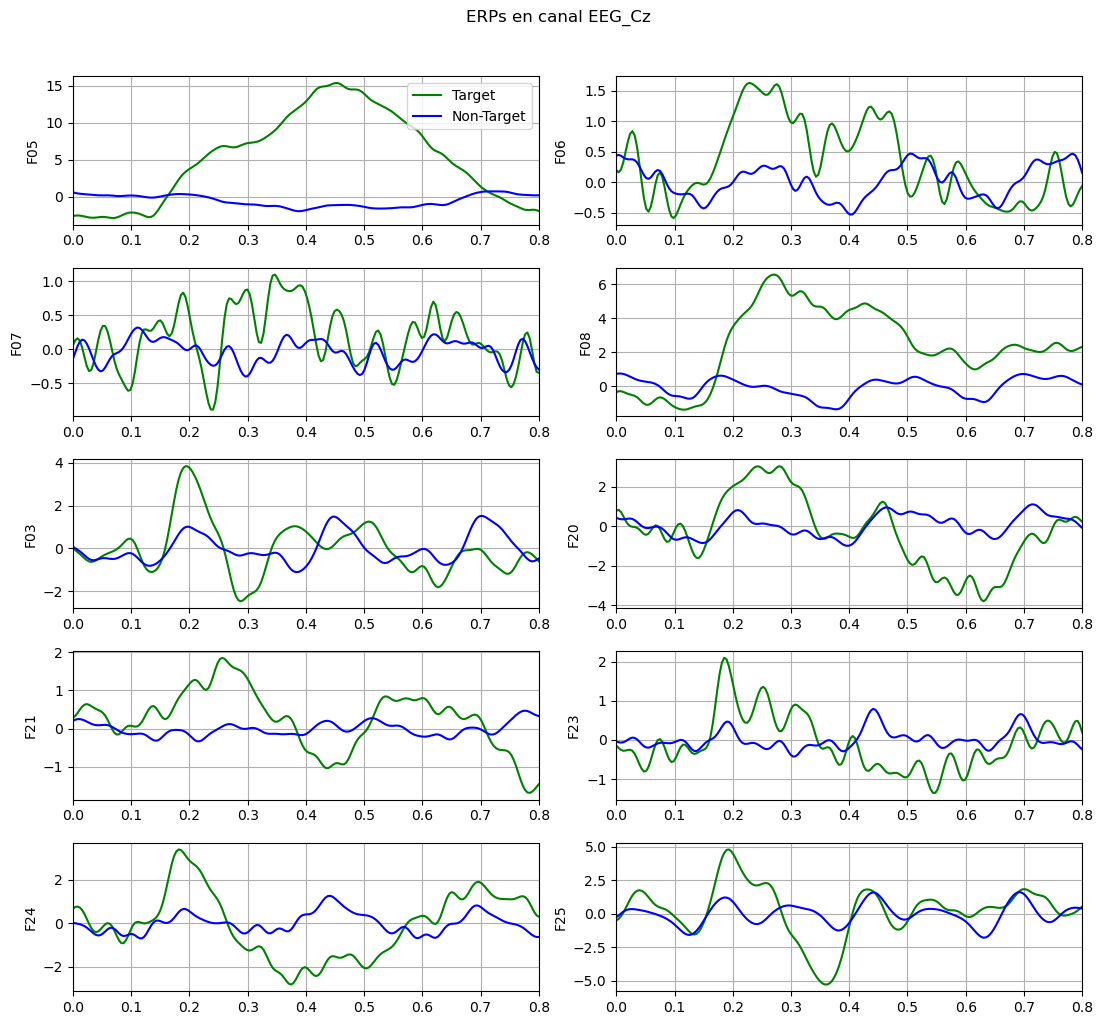

In [66]:
plot_erps_by_channel('EEG_Cz')

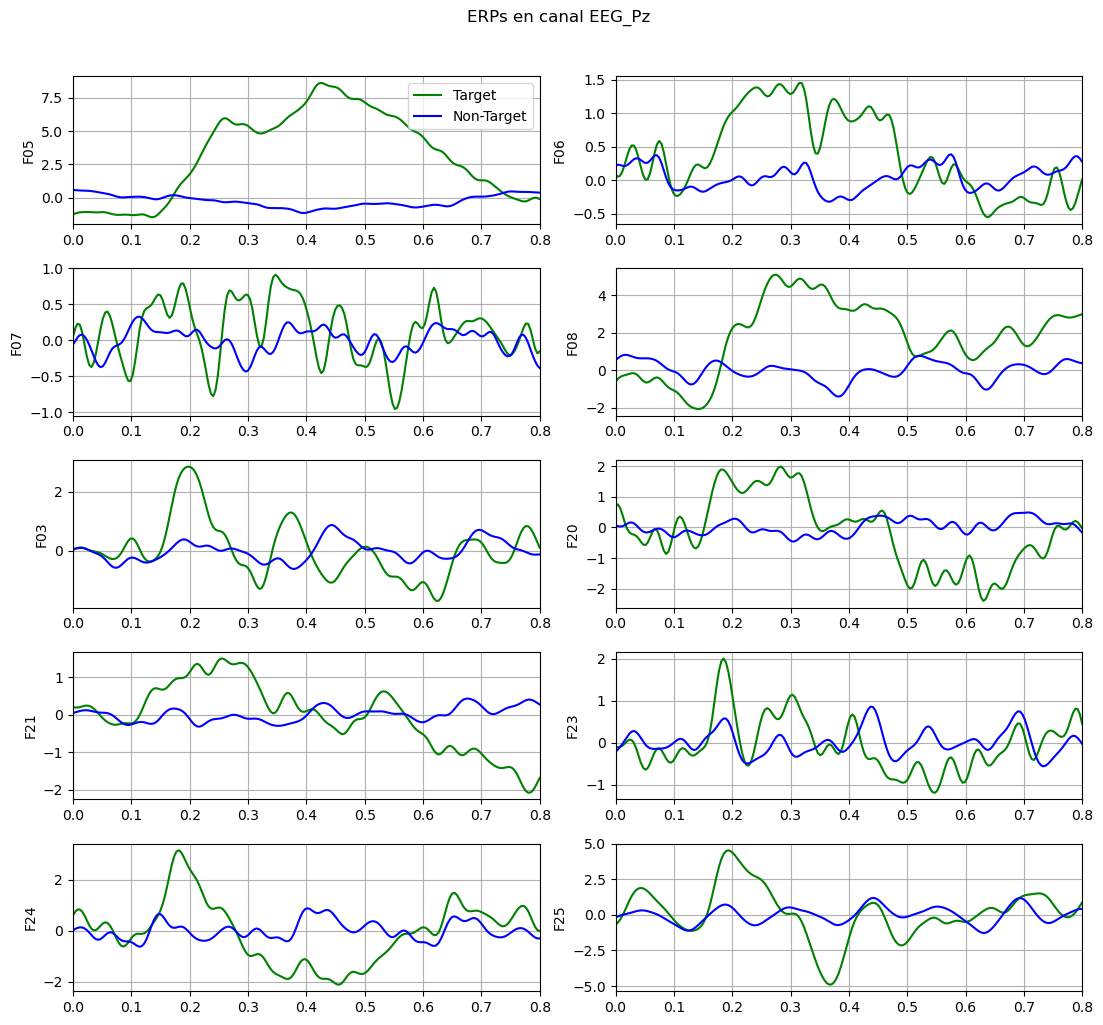

In [54]:
plot_erps_by_channel('EEG_Pz') 

# **Segmentación del ERP en las señales EEG**

In [6]:
def obtener_tramos_eeg_con_etiquetas(sujeto_id, canal_eeg, fs=256, base_path="./StudyF"):
    """
    Carga todos los archivos de entrenamiento de un sujeto, identifica los eventos 
    StimulusType y StimulusBegin, y extrae los intervalos target y non-target 
    conservando su posición en la señal continua.

    Args:
        sujeto_id (str): ID del sujeto (e.g., 'F_03')
        canal_eeg (str): Canal EEG de interés (e.g., 'EEG_Pz')
        fs (int): Frecuencia de muestreo (Hz)
        base_path (str): Ruta base a los archivos EDF

    Returns:
        eeg_data (np.ndarray): Señal EEG continua
        tramos (list): Lista de tuplas (inicio, fin, etiqueta), donde etiqueta ∈ {'target', 'non-target'}
        time (np.ndarray): Vector de tiempo correspondiente a eeg_data
    """

    archivos = listar_archivos_train(base_path)
    df, raw_info = cargar_edf_sujeto(sujeto_id, archivos)

    stim_type = (df['StimulusType'].to_numpy() == 1000000.0)
    stim_begin = (df['StimulusBegin'].to_numpy() == 1000000.0)
    joint_signal = stim_begin
    edges = np.diff(joint_signal.astype(int), prepend=0)
    event_indices = np.where(edges == 1)[0]

    eeg_data = df[canal_eeg].values
    time = np.arange(len(eeg_data)) / fs

    pre = 0
    post = int(0.8 * fs)

    tramos = []
    for t in event_indices:
        if t + post < len(eeg_data):
            etiqueta = 'target' if stim_type[t] else 'non-target'
            tramos.append((t, t + post, etiqueta))

    return eeg_data, tramos, time

In [11]:
archivos = listar_archivos_train("./StudyF")
df, raw_info = cargar_edf_sujeto("F_03", archivos)
time = df['time'].to_numpy()
stim_type = (df['StimulusType'].to_numpy() == 1000000.0)
stim_begin = (df['StimulusBegin'].to_numpy() == 1000000.0)
eeg_data, tramos, time = obtener_tramos_eeg_con_etiquetas("F_03", "EEG_Pz")

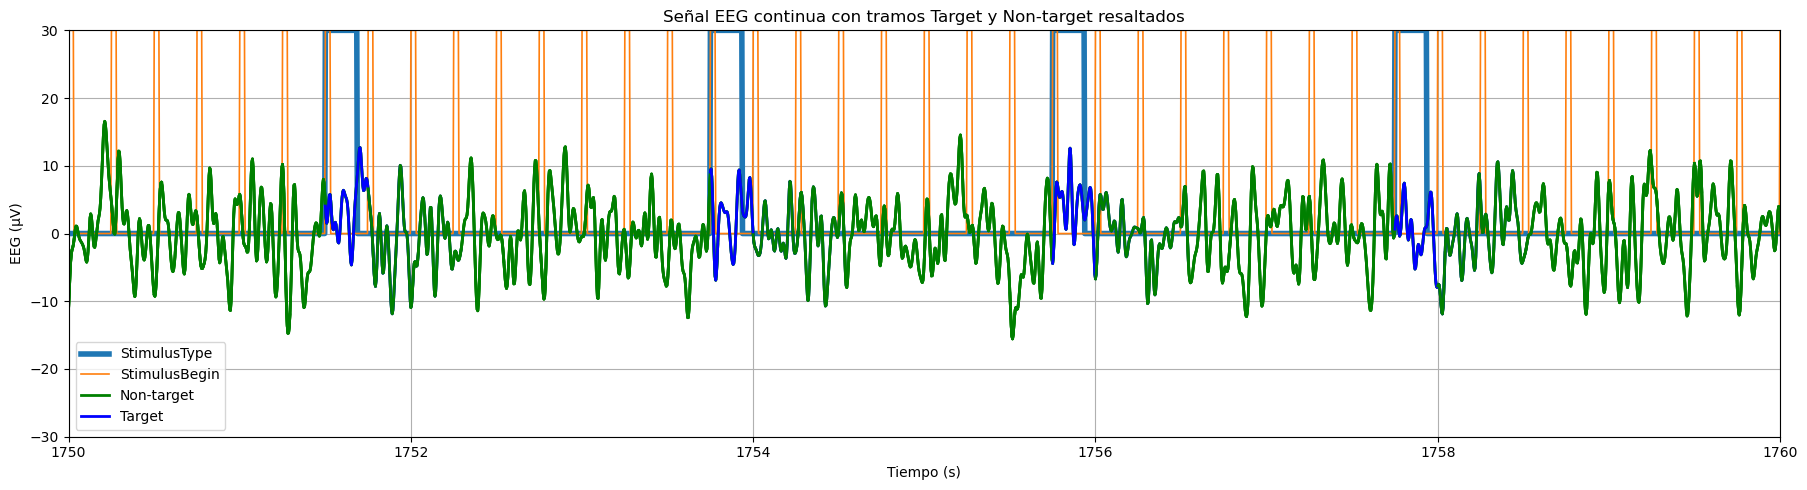

In [12]:
plt.figure(figsize=(18, 5))
plt.plot(time, 30*stim_type, label='StimulusType', linewidth=4)
plt.plot(time, 30*stim_begin, label='StimulusBegin', linewidth=1.2)
plt.plot(time, eeg_data, color='black', linewidth=0.8)

for inicio, fin, etiqueta in tramos:
    if etiqueta == 'target':
        plt.plot(time[inicio:fin], eeg_data[inicio:fin], color='blue', linewidth=2, label='Target' if 'Target' not in plt.gca().get_legend_handles_labels()[1] else "")
    else:
        plt.plot(time[inicio:fin], eeg_data[inicio:fin], color='green', linewidth=2, label='Non-target' if 'Non-target' not in plt.gca().get_legend_handles_labels()[1] else "")

plt.xlabel("Tiempo (s)")
plt.ylabel("EEG (μV)")
plt.title("Señal EEG continua con tramos Target y Non-target resaltados")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.xlim([1750, 1760])  # Ajusta para ver solo una parte si es muy largo
plt.ylim([-30, 30]) 
plt.show()